## Trabajo Final Python For Data Science Juan Corazzo



In [48]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
import numpy as np
import plotly.express as px
import streamlit
from pandas import read_csv



## 1.Definicion del problema

>Para esta oportunidad nos interesa saber que cantidad de transacciones aceptadas por adquiriente

## 2.Recopilación de datos
> Dataset de compras según comercio, tarjeta, país y adquiriente


|      Variable       |            Definicion             |                       Key                       |
|:-------------------:|:---------------------------------:|:-----------------------------------------------:|
|   operation_date    |       fecha de la operación       |                                                 |
|     ID COMERCIO     | Número identificador del comercio |                                                 |
|  ID UNICO DE PAGO   |      Identificador del pago       |                                                 |
|    payment_type     |           Tipo de Pago            |                   order/rider                   |
|  transaccion_type   |        Tipo de transaccion        |                                                 |
|      card_type      |       Emisor de la tarjeta        |       Visa, American, Master, Desconocido       |
| card_operation_type |          Tipo de tarjeta          |                 Débito/Crédito                  |
| authorization_code  |      Código de autorización       |                                                 |
|       status        |        Estado de la compra        |                                                 |
|       Importe       |       Importe de la compra        |                                                 |
|      Impuestos      |      Impuestos de la compra       |                                                 |
|        País         |         País de la compra         | Argentina, Chile, Brasil, El Salvador, Paraguay |
|      card_bin       |         Bin de la tarjeta         |                                                 |
|  card_last_digits   |   Últimos números de la tarjeta   |                                                 |
|      Acquirer       |            Adquiriente            |                  COSMIC/INDIE                   |
|        state        |     Estado Final de la compra     |                                                 |
|      COMISION       |             Comisión              |                                                 |

## Importamos la base de datos


In [49]:
df = pd.read_csv("../data/raw/p4ds-base-para-facultad.csv")
df

,Unnamed: 0,operation_date,ID COMERCIO,ID UNICO DE PAGO,payment_type,ID COMERCIO.1,transaction_type,card_type,card_operation_type,authorization_code,status,Importe,Impuestos,country,card_bin,card_last_digits,acquirer,state,COMISION
0,0,01-01-2026,8.212115e+09,5237267545,ORDER,1.020226e+07,PAY,AMERICAN,CREDIT,424291,ACCEPTED,3500,70,PA,751494,7248,COSMIC,ACCEPTED,0.05
1,1,02-01-2026,8.213788e+09,5237267356,ORDER,1.012380e+08,PAY,VISA,CREDIT,529598,ACCEPTED,7500,140,AR,477701,7571,COSMIC,ACCEPTED,0.05
2,2,03-01-2026,8.212115e+09,5237267170,RIDER,1.020241e+07,PAY,AMERICAN,CREDIT,479438,ACCEPTED,4000,20,SV,751494,7725,COSMIC,ACCEPTED,0.05
3,3,04-01-2026,8.212114e+09,5237267087,ORDER,1.012380e+08,PAY,VISA,CREDIT,359263,ACCEPTED,7500,20,PA,470270,3223,COSMIC,ACCEPTED,0.05
4,4,05-01-2026,8.213279e+09,5237267021,ORDER,1.012380e+08,PAY,VISA,CREDIT,329232,ACCEPTED,4500,90,AR,479464,7875,COSMIC,ACCEPTED,0.05
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
30757,30757,05-02-2026,8.213279e+09,5234498019,ORDER,1.015350e+09,PAY,VISA,CREDIT,882232,ACCEPTED,46000,870,PA,479464,4444,COSMIC,ACCEPTED,0.05
30758,30758,07-02-2026,8.212114e+09,5234497943,ORDER,1.015350e+09,PAY,VISA,CREDIT,714316,ACCEPTED,51000,970,SV,470270,1424,COSMIC,ACCEPTED,0.05
30759,30759,08-02-2026,8.212118e+09,5234497866,ORDER,1.015350e+09,PAY,VISA,CREDIT,253927,ACCEPTED,71500,1360,PA,477674,1007,COSMIC,ACCEPTED,0.05
30760,30760,09-02-2026,8.212110e+09,5234497855,ORDER,1.015350e+09,PAY,VISA,CREDIT,115875,ACCEPTED,341625,6490,AR,470270,2015,COSMIC,ACCEPTED,0.05


## 3 Análisis descriptivo


In [50]:
# Obtenemos las dimensiones
df.shape


(30762, 19)

La base de datos contiene 30762 filas y 19 columnas

In [51]:
# Obtenemos información sobre los tipos de datos y valores no nulos
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 30762 entries, 0 to 30761
Data columns (total 19 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Unnamed: 0           30762 non-null  int64  
 1   operation_date       30762 non-null  str    
 2   ID COMERCIO          30251 non-null  float64
 3   ID UNICO DE PAGO     30762 non-null  int64  
 4   payment_type         30762 non-null  str    
 5   ID COMERCIO.1        30120 non-null  float64
 6   transaction_type     30762 non-null  str    
 7   card_type            30762 non-null  str    
 8   card_operation_type  30762 non-null  str    
 9   authorization_code   29980 non-null  str    
 10  status               30762 non-null  str    
 11  Importe              30762 non-null  int64  
 12  Impuestos            30762 non-null  int64  
 13  country              30762 non-null  str    
 14  card_bin             30762 non-null  int64  
 15  card_last_digits     30762 non-null  int64  
 1

In [52]:
df.describe().T


,count,mean,std,min,25%,50%,75%,max
Unnamed: 0,30762.0,1.538050e+04,8.880369e+03,0.000000e+00,7.690250e+03,1.538050e+04,2.307075e+04,3.076100e+04
ID COMERCIO,30251.0,8.212274e+09,4.004636e+05,8.212106e+09,8.212114e+09,8.212115e+09,8.212117e+09,8.214236e+09
ID UNICO DE PAGO,30762.0,5.188860e+09,3.080020e+08,3.174969e+09,5.235118e+09,5.235999e+09,5.236881e+09,5.237268e+09
ID COMERCIO.1,30120.0,4.040826e+10,2.671162e+10,1.006573e+07,1.020242e+07,5.808018e+10,5.808018e+10,5.808018e+10
Importe,30762.0,5.859597e+04,5.491035e+04,1.000000e+02,2.700000e+04,4.700000e+04,7.700000e+04,1.473002e+06
Impuestos,30762.0,1.049225e+03,1.064827e+03,0.000000e+00,2.700000e+02,8.400000e+02,1.420000e+03,2.799000e+04
card_bin,30762.0,7.205127e+05,1.245142e+06,0.000000e+00,7.101750e+05,7.187970e+05,7.671260e+05,7.766871e+07
card_last_digits,30762.0,4.941905e+03,2.822715e+03,0.000000e+00,2.452000e+03,4.873000e+03,7.757000e+03,8.888000e+03
COMISION,30762.0,7.074410e-02,1.385682e-02,5.000000e-02,5.000000e-02,8.000000e-02,8.000000e-02,8.000000e-02


# Observaciones

- El dataframe consiste en 30762 filas y 19 columnas
- La variable `ID COMERCIO`  cuenta con al menos 500 valores nulos
- La variable `ID COMERCIO.1` cueenta también con al menos 500 valores nulos
- El resto de las variables no cuenta con valores nulos


## 4 Limpieza de Datos


In [53]:
df.duplicated()


0        False
1        False
2        False
3        False
4        False
         ...  
30757    False
30758    False
30759    False
30760    False
30761    False
Length: 30762, dtype: bool

No se encuentran valores duplicados


 Definimos las variables que no van a ser utilizadas en el modelo predictivo:
 `Unnamed`, `ID COMERCIO`, `ID COMERCIO.1`, `authorization_code`, `Impuestos`, `card_bin` `card_last_digits` `COMISION`

In [54]:
df.drop(["Unnamed: 0", "ID COMERCIO", "ID UNICO DE PAGO", "ID COMERCIO.1",  "authorization_code", "Impuestos", "card_bin", "card_last_digits", "COMISION", "payment_type", "operation_date", "Importe" ], axis=1, inplace=True)
df

,transaction_type,card_type,card_operation_type,status,country,acquirer,state
0,PAY,AMERICAN,CREDIT,ACCEPTED,PA,COSMIC,ACCEPTED
1,PAY,VISA,CREDIT,ACCEPTED,AR,COSMIC,ACCEPTED
2,PAY,AMERICAN,CREDIT,ACCEPTED,SV,COSMIC,ACCEPTED
3,PAY,VISA,CREDIT,ACCEPTED,PA,COSMIC,ACCEPTED
4,PAY,VISA,CREDIT,ACCEPTED,AR,COSMIC,ACCEPTED
...,...,...,...,...,...,...,...
30757,PAY,VISA,CREDIT,ACCEPTED,PA,COSMIC,ACCEPTED
30758,PAY,VISA,CREDIT,ACCEPTED,SV,COSMIC,ACCEPTED
30759,PAY,VISA,CREDIT,ACCEPTED,PA,COSMIC,ACCEPTED
30760,PAY,VISA,CREDIT,ACCEPTED,AR,COSMIC,ACCEPTED


## 4.Análisis de variables

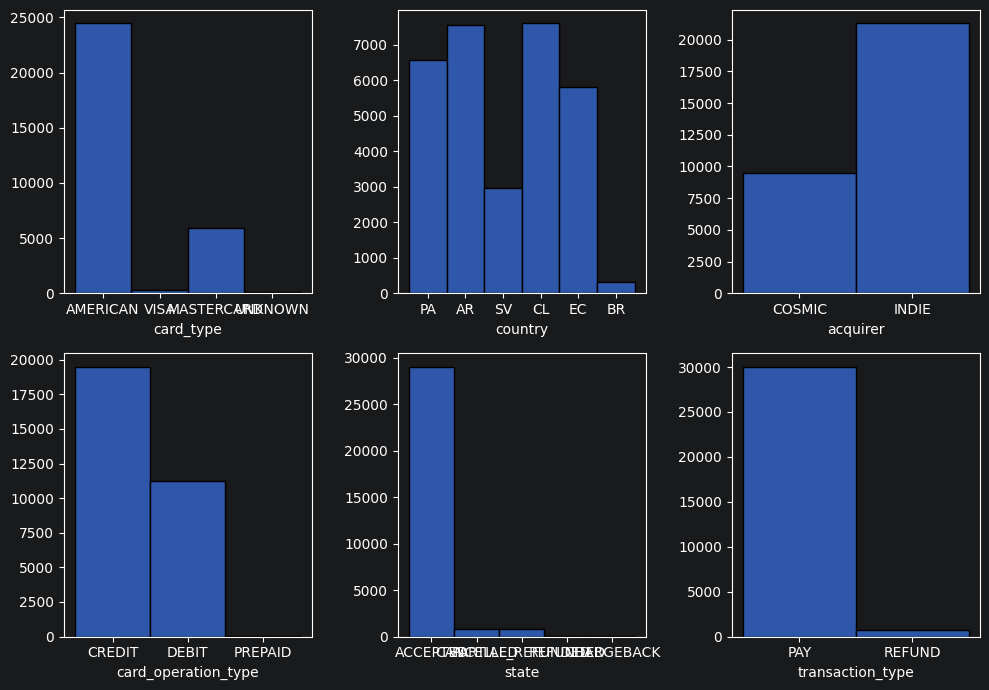

In [55]:
fig, axis = plt.subplots(2, 3, figsize=(10, 7))

sns.histplot(ax=axis[0,0], data=df, x="card_type").set(ylabel=None)
sns.histplot(ax=axis[0,1], data=df, x="country").set(ylabel=None)
sns.histplot(ax=axis[0,2], data=df, x="acquirer").set(ylabel=None)
sns.histplot(ax=axis[1,0], data=df, x="card_operation_type").set(ylabel=None)
sns.histplot(ax=axis[1,1], data=df, x="state").set(ylabel=None)
sns.histplot(ax=axis[1,2], data=df, x="transaction_type").set(ylabel=None)

plt.tight_layout()
plt.show()

>### Observaciones
>
> - **Card_Type**: el número de transacciones realizadas con tarjetas American quintuplican a las que se realizan con el resto de tarjeta
> - **Country**: Argentina y Chile son los países con más transacciones realizadas.
> - **Acquirer**: Las compras realizadas por INDIE son de más del doble de las realizadas por COSMIC
> - **card_operation_type**: Las compras fueron realizadas mayormente con tarjeta de crédito, no se encuentran registors de pago con prepaid
> - **state**: La gran mayoria de las transacciones fueron aceptadas
> - **transaction_type**: Las transacciones que fueron de pago son ampliamente superiores a las de reembolso

## Análisis de variables categóricas
Analizamos el resto de variables con nuestra variable target que es acquirer

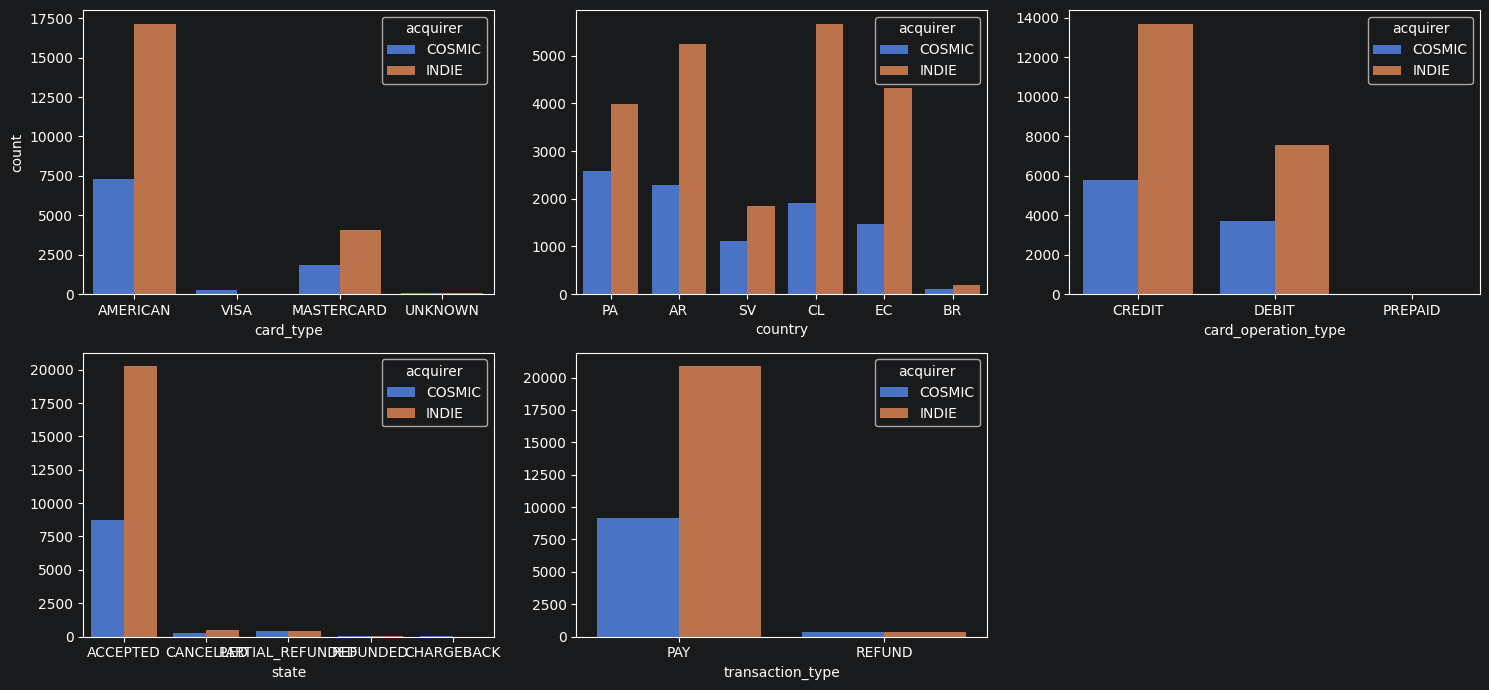

In [56]:
fig, axis = plt.subplots(2, 3, figsize=(15, 7))

sns.countplot(ax=axis[0, 0], data=df, x="card_type", hue="acquirer")
sns.countplot(ax=axis[0, 1], data=df, x="country", hue="acquirer").set(ylabel=None)
sns.countplot(ax=axis[0, 2], data=df, x="card_operation_type", hue="acquirer").set(ylabel=None)
sns.countplot(ax=axis[1, 0], data=df, x="state", hue="acquirer").set(ylabel=None)
sns.countplot(ax=axis[1, 1], data=df, x="transaction_type", hue="acquirer").set(ylabel=None)
fig.delaxes(axis[1, 2])

plt.tight_layout()
plt.show()

Análisis de correlaciones

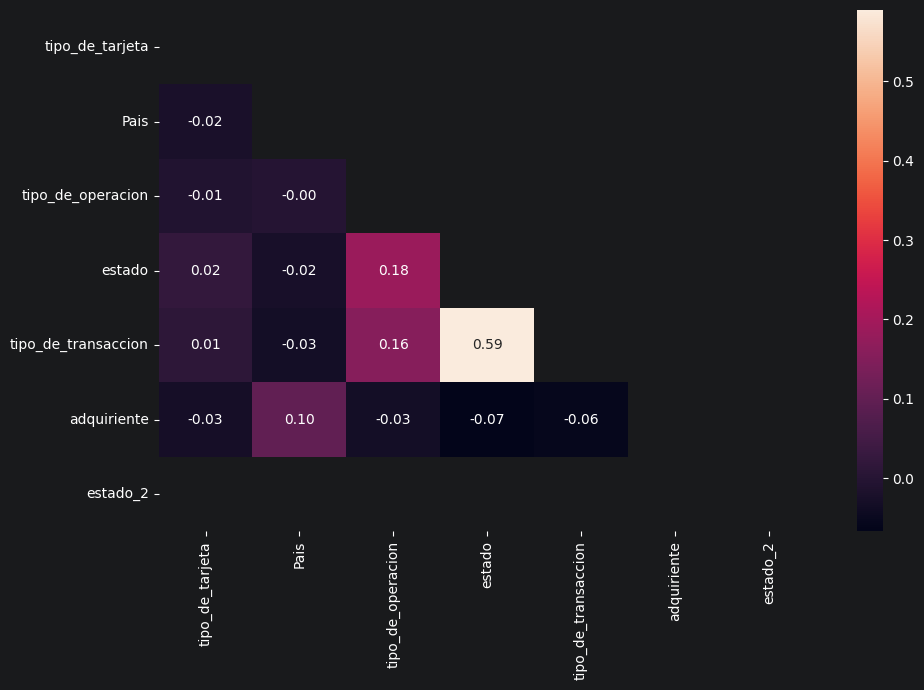

In [57]:
# Creo columnas numéricas para las variables categóricas
df["tipo_de_tarjeta"] = pd.factorize(df["card_type"])[0]
df["Pais"] = pd.factorize(df["country"])[0]
df["tipo_de_operacion"] = pd.factorize(df["card_operation_type"])[0]
df["estado"] = pd.factorize(df["state"])[0]
df["tipo_de_transaccion"] = pd.factorize(df["transaction_type"])[0]
df["adquiriente"] = pd.factorize(df["acquirer"])[0]
df["estado_2"] = pd.factorize(df["status"])[0]

corr = df[["tipo_de_tarjeta", "Pais", "tipo_de_operacion", "estado", "tipo_de_transaccion", "adquiriente", "estado_2"]].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, axis = plt.subplots(figsize=(10, 7))
sns.heatmap(corr, mask=mask, annot=True, fmt=".2f")

plt.tight_layout()
plt.show()


Observaciones

> Existe una fuerte correlación entre el tipo de transaccion y el adquiriente, para el resto de correlaciones no son lo suficientemente fuertes

## 6.Ingeniería de características


In [58]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_de_tarjeta,30762.0,0.406280,0.807991,0.0,0.0,0.0,0.0,3.0
Pais,30762.0,1.981471,1.479413,0.0,1.0,2.0,3.0,5.0
tipo_de_operacion,30762.0,0.367174,0.483994,0.0,0.0,0.0,1.0,2.0
estado,30762.0,0.090501,0.397811,0.0,0.0,0.0,0.0,4.0
tipo_de_transaccion,30762.0,0.023698,0.152109,0.0,0.0,0.0,0.0,1.0
adquiriente,30762.0,0.691470,0.461894,0.0,0.0,1.0,1.0,1.0
estado_2,30762.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


In [59]:
df.shape[0]

30762

In [60]:
df.isnull().sum()

transaction_type       0
card_type              0
card_operation_type    0
status                 0
country                0
acquirer               0
state                  0
tipo_de_tarjeta        0
Pais                   0
tipo_de_operacion      0
estado                 0
tipo_de_transaccion    0
adquiriente            0
estado_2               0
dtype: int64

No se encuentran valores nulos para las columnas del dataframe

## 7. Split

**Enfoque 1:** Primero procesamos todo el dataset y luego lo dividimos.

Pasos:
1. Eliminar la columna status (sigue siendo texto, ya la tenemos codificada como estado_2 )
2. Separar el dataset en **X** (variables de entrada) e **y** (variable objetivo: )
3. Dividir en **train** (80%) y **test** (20%)

In [61]:
df.drop(["card_type", "country", "card_operation_type", "state", "transaction_type", "acquirer" ], axis=1, inplace=True)

In [62]:
df

,status,tipo_de_tarjeta,Pais,tipo_de_operacion,estado,tipo_de_transaccion,adquiriente,estado_2
0,ACCEPTED,0,0,0,0,0,0,0
1,ACCEPTED,1,1,0,0,0,0,0
2,ACCEPTED,0,2,0,0,0,0,0
3,ACCEPTED,1,0,0,0,0,0,0
4,ACCEPTED,1,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...
30757,ACCEPTED,1,0,0,0,0,0,0
30758,ACCEPTED,1,2,0,0,0,0,0
30759,ACCEPTED,1,0,0,0,0,0,0
30760,ACCEPTED,1,1,0,0,0,0,0


In [63]:

# 1. Eliminamos la columna status (sigue siendo string, ya codificada como estado_2)
df.drop(["status"], axis=1, inplace=True)
df.head()

,tipo_de_tarjeta,Pais,tipo_de_operacion,estado,tipo_de_transaccion,adquiriente,estado_2
0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0
2,0,2,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,1,0,0,0,0,0


In [64]:
# 2. Separamos X (features) e y (target)
X = df.drop("adquiriente", axis=1)
y = df["adquiriente"]

print("Shape de X:", X.shape)
print("Shape de y:", y.shape)
X.head()

Shape de X: (30762, 6)
Shape de y: (30762,)


,tipo_de_tarjeta,Pais,tipo_de_operacion,estado,tipo_de_transaccion,estado_2
0,0,0,0,0,0,0
1,1,1,0,0,0,0
2,0,2,0,0,0,0
3,1,0,0,0,0,0
4,1,1,0,0,0,0


In [65]:
# 3. Dividimos en train (80%) y test (20%)
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2,
                                                    random_state=42)

print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

X_train: (24609, 6)
X_test:  (6153, 6)
y_train: (24609,)
y_test:  (6153,)


## 8. Scaling & Encoding

**Encoding:** Ya realizado en el Paso 6.

**Scaling (Enfoque 1):** Entrenamos el escalador mirando todo el dataset  (train + test juntos), y luego aplicamos esa misma escala y usamos  que lleva todos los valores al rango **0 a 1**.

In [66]:
from sklearn.preprocessing import MinMaxScaler

# Enfoque 1: el escalador aprende los parametros de TODO X (train + test)
scaler = MinMaxScaler()
scaler.fit(X)

# Aplicamos la transformacion a ambos conjuntos
X_train_scaled = scaler.transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Convertimos el resultado de vuelta a DataFrame para mantener los nombres de columnas
X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled = pd.DataFrame(X_test_scaled, columns=X.columns, index=X_test.index)

X_train_scaled.head()

,tipo_de_tarjeta,Pais,tipo_de_operacion,estado,tipo_de_transaccion,estado_2
2748,0.0,0.8,0.5,0.0,0.0,0.0
24502,0.0,0.0,0.0,0.0,0.0,0.0
8005,0.0,0.2,0.0,0.0,0.0,0.0
25886,0.0,0.6,0.0,0.0,0.0,0.0
17465,0.0,0.2,0.0,0.0,0.0,0.0


In [67]:
    # Verificamos que los valores esten en el rango 0 a 1
X_train_scaled.describe().T

,count,mean,std,min,25%,50%,75%,max
tipo_de_tarjeta,24609.0,0.135140,0.268951,0.0,0.0,0.0,0.0,1.0
Pais,24609.0,0.395213,0.295900,0.0,0.2,0.4,0.6,1.0
tipo_de_operacion,24609.0,0.183876,0.242237,0.0,0.0,0.0,0.5,1.0
estado,24609.0,0.023091,0.100124,0.0,0.0,0.0,0.0,1.0
tipo_de_transaccion,24609.0,0.024178,0.153605,0.0,0.0,0.0,0.0,1.0
estado_2,24609.0,0.000000,0.000000,0.0,0.0,0.0,0.0,0.0


## 9. Seleccion de Caracteristicas

Lo utilizamos para puntuar cada variable segun que tan relacionada esta con el target (). Primero vemos los puntajes de todas las variables para decidir cuantas conservar.

In [68]:
from sklearn.feature_selection import f_classif, SelectKBest

# Calculamos el puntaje de cada variable
scores, p_values = f_classif(X_train_scaled, y_train)

# Mostramos los resultados ordenados de mayor a menor puntaje
import pandas as pd
scores_df = pd.DataFrame({
    "variable": X_train_scaled.columns,
    "puntaje": scores,
    "p_value": p_values
}).sort_values("puntaje", ascending=False)

scores_df

C:\Users\jcora\PycharmProjects\python-for-data-final\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [5] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\jcora\PycharmProjects\python-for-data-final\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


,variable,puntaje,p_value
1,Pais,252.871417,1.177326e-56
3,estado,114.908762,9.441245e-27
4,tipo_de_transaccion,78.925538,6.880947e-19
2,tipo_de_operacion,25.402018,4.687281e-07
0,tipo_de_tarjeta,25.358589,4.793892e-07
5,estado_2,NaN,NaN


In [69]:
# Aplicamos SelectKBest con k=5 (eliminamos la variable con menor puntaje)
selection_model = SelectKBest(f_classif, k=5)
selection_model.fit(X_train_scaled, y_train)

# Obtenemos las columnas seleccionadas
ix = selection_model.get_support()
columnas_seleccionadas = X_train_scaled.columns[ix].tolist()
print("Columnas seleccionadas:", columnas_seleccionadas)
print("Columna eliminada:", X_train_scaled.columns[~ix].tolist())

Columnas seleccionadas: ['tipo_de_tarjeta', 'Pais', 'tipo_de_operacion', 'estado', 'tipo_de_transaccion']
Columna eliminada: ['estado_2']


C:\Users\jcora\PycharmProjects\python-for-data-final\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:110: UserWarning: Features [5] are constant.
  warnings.warn("Features %s are constant." % constant_features_idx, UserWarning)
C:\Users\jcora\PycharmProjects\python-for-data-final\.venv\Lib\site-packages\sklearn\feature_selection\_univariate_selection.py:111: RuntimeWarning: invalid value encountered in divide
  f = msb / msw


In [70]:
# Creamos los datasets finales con las caracteristicas seleccionadas
X_train_sel = pd.DataFrame(
    selection_model.transform(X_train_scaled),
    columns=columnas_seleccionadas,
    index=X_train_scaled.index
)

X_test_sel = pd.DataFrame(
    selection_model.transform(X_test_scaled),
    columns=columnas_seleccionadas,
    index=X_test_scaled.index
)

print("Shape X_train final:", X_train_sel.shape)
print("Shape X_test final: ", X_test_sel.shape)
X_train_sel.head()

Shape X_train final: (24609, 5)
Shape X_test final:  (6153, 5)


,tipo_de_tarjeta,Pais,tipo_de_operacion,estado,tipo_de_transaccion
2748,0.0,0.8,0.5,0.0,0.0
24502,0.0,0.0,0.0,0.0,0.0
8005,0.0,0.2,0.0,0.0,0.0
25886,0.0,0.6,0.0,0.0,0.0
17465,0.0,0.2,0.0,0.0,0.0


## Grabacion del Dataset Procesado



In [71]:
# Combinamos X e y en un solo DataFrame para guardar
df_procesado = X.copy()
df_procesado["adquiriente"] = y

# Guardamos en data/processed/
df_procesado.to_csv("../data/processed/transacciones_procesadas.csv", index=False)

print("Dataset guardado correctamente.")
print("Shape:", df_procesado.shape)
print("Columnas:", df_procesado.columns.tolist())
df_procesado.head()

Dataset guardado correctamente.
Shape: (30762, 7)
Columnas: ['tipo_de_tarjeta', 'Pais', 'tipo_de_operacion', 'estado', 'tipo_de_transaccion', 'estado_2', 'adquiriente']


,tipo_de_tarjeta,Pais,tipo_de_operacion,estado,tipo_de_transaccion,estado_2,adquiriente
0,0,0,0,0,0,0,0
1,1,1,0,0,0,0,0
2,0,2,0,0,0,0,0
3,1,0,0,0,0,0,0
4,1,1,0,0,0,0,0


## Grabacion del Dataset para la App Streamlit

Guardamos una version del dataset con los valores originales (sin codificar) para que la app Streamlit pueda mostrar etiquetas legibles. Incluimos  como columna numerica para el slider.

In [72]:
# Cargamos el CSV original nuevamente para obtener los valores sin codificar
df_app = pd.read_csv("../data/raw/p4ds-base-para-facultad.csv")

# Seleccionamos solo las columnas utiles para la app
df_app = df_app[["Importe", "card_type", "country", "card_operation_type", "transaction_type", "acquirer", "state"]]

# Eliminamos filas con nulos (si hubiera)
df_app = df_app.dropna()

# Guardamos en data/processed/
df_app.to_csv("../data/processed/transacciones_app.csv", index=False)

print("Dataset para app guardado correctamente.")
print("Shape:", df_app.shape)
print("Columnas:", df_app.columns.tolist())
df_app.head()

Dataset para app guardado correctamente.
Shape: (30762, 7)
Columnas: ['Importe', 'card_type', 'country', 'card_operation_type', 'transaction_type', 'acquirer', 'state']


,Importe,card_type,country,card_operation_type,transaction_type,acquirer,state
0,3500,AMERICAN,PA,CREDIT,PAY,COSMIC,ACCEPTED
1,7500,VISA,AR,CREDIT,PAY,COSMIC,ACCEPTED
2,4000,AMERICAN,SV,CREDIT,PAY,COSMIC,ACCEPTED
3,7500,VISA,PA,CREDIT,PAY,COSMIC,ACCEPTED
4,4500,VISA,AR,CREDIT,PAY,COSMIC,ACCEPTED
